Max Loss for 30 EEG Channels: 0.6930
Max Loss for 20 EEG Channel: 0.6930
Max Loss for 11 EEG Channel: 0.6930


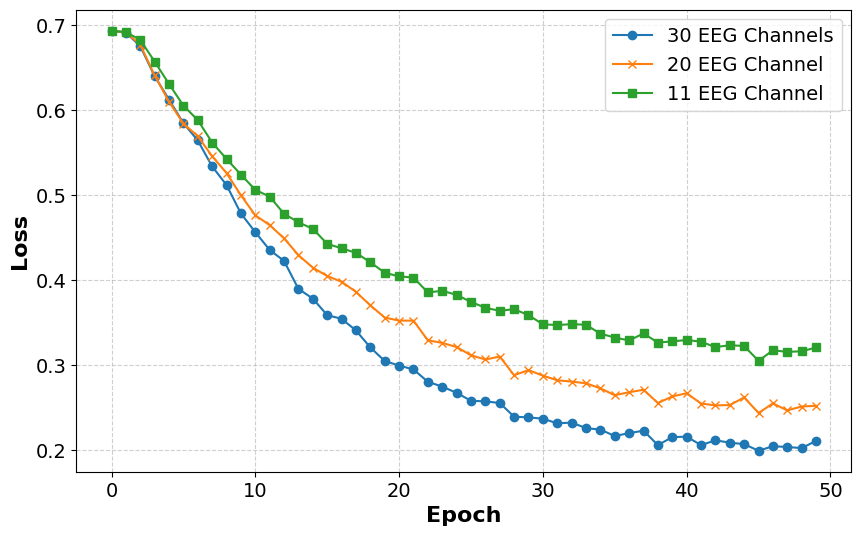

Max Loss for 30 EEG Channels: 0.6921
Max Loss for 20 EEG Channel: 0.8069
Max Loss for 11 EEG Channel: 0.8357


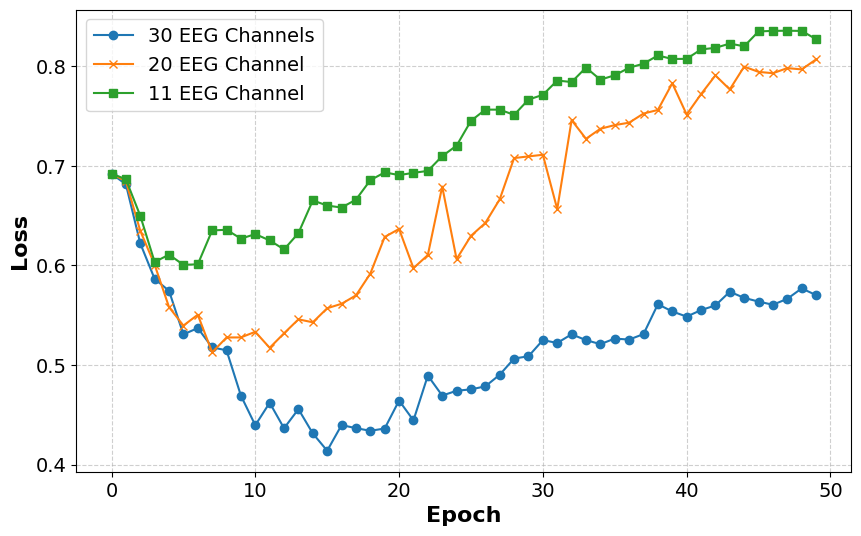

Max Loss for 30 EEG Channels: 0.8654
Max Loss for 20 EEG Channel: 0.9493
Max Loss for 11 EEG Channel: 0.8485


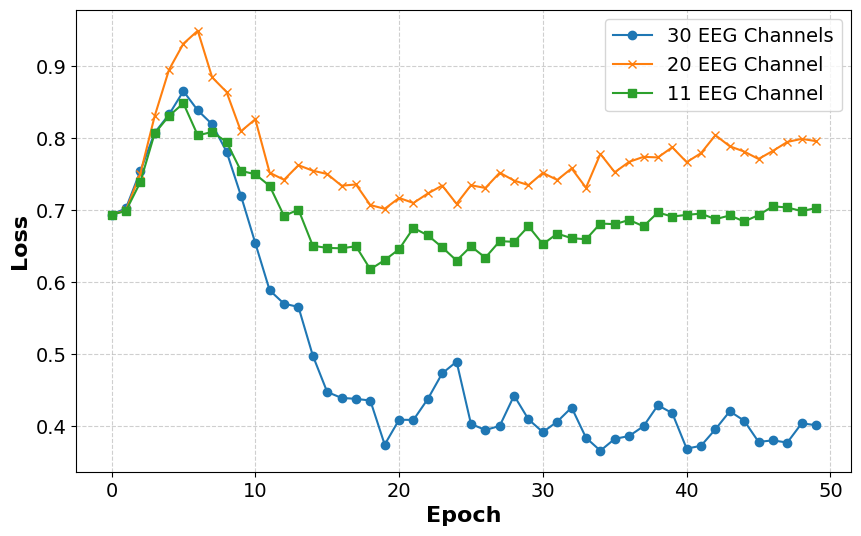

Max Accuracy for 30 EEG Channels: 0.9241
Max Accuracy for 20 EEG Channel: 0.8999
Max Accuracy for 11 EEG Channel: 0.8779


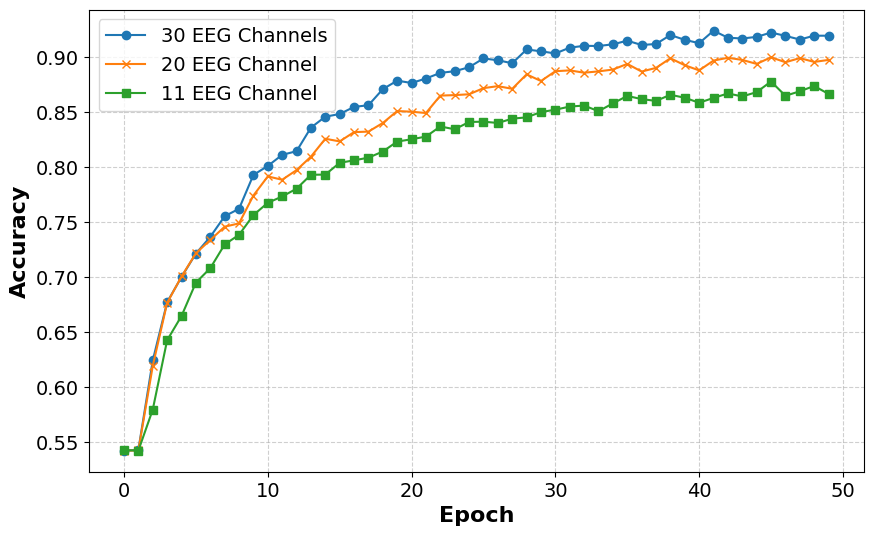

Max Accuracy for 30 EEG Channels: 0.8214
Max Accuracy for 20 EEG Channel: 0.7558
Max Accuracy for 11 EEG Channel: 0.6905


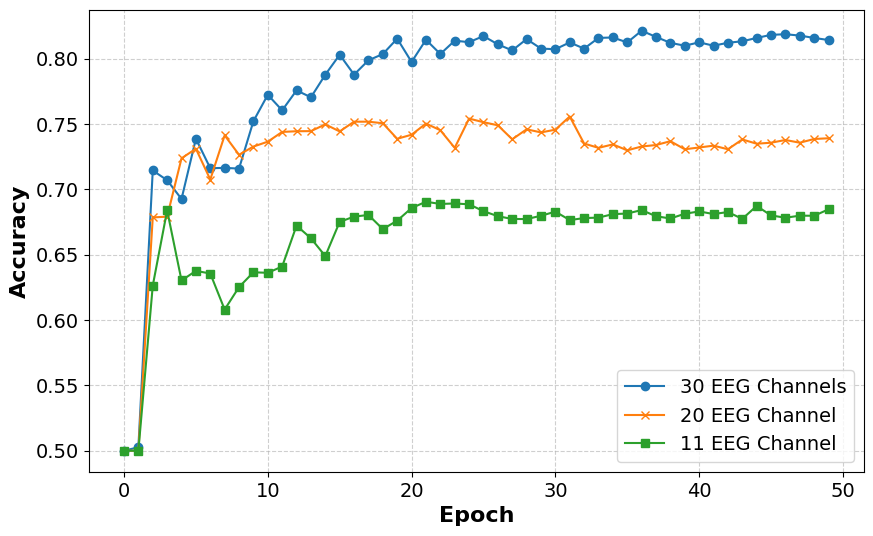

Max Balanced Accuracy for 30 EEG Channels: 0.8541
Max Balanced Accuracy for 20 EEG Channel: 0.7226
Max Balanced Accuracy for 11 EEG Channel: 0.7289


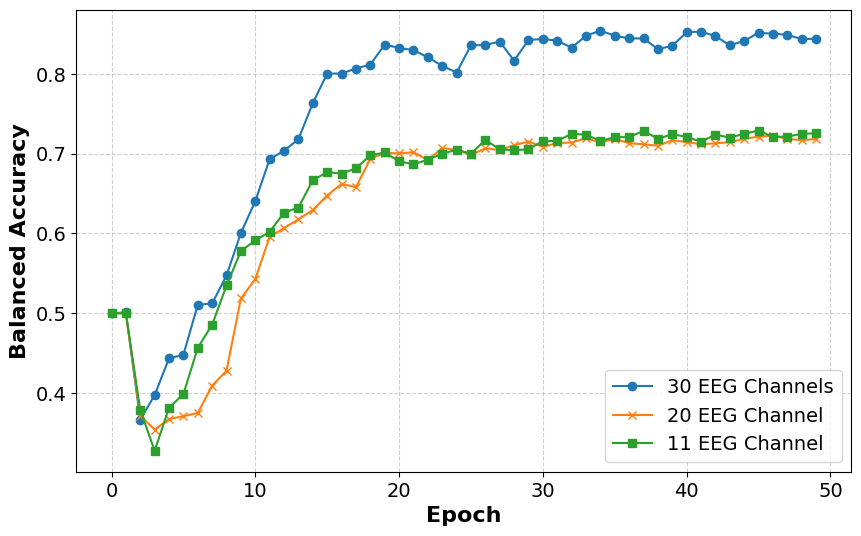

Max ROC AUC for 30 EEG Channels: 0.9317
Max ROC AUC for 20 EEG Channel: 0.8360
Max ROC AUC for 11 EEG Channel: 0.8551


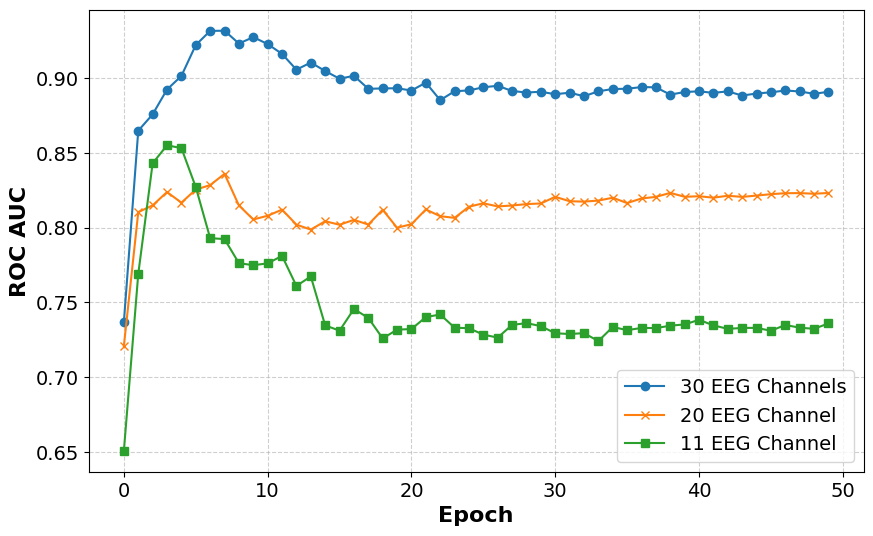

Max ROC AUC for 30 EEG Channels: 0.9505
Max ROC AUC for 20 EEG Channel: 0.7589
Max ROC AUC for 11 EEG Channel: 0.8103


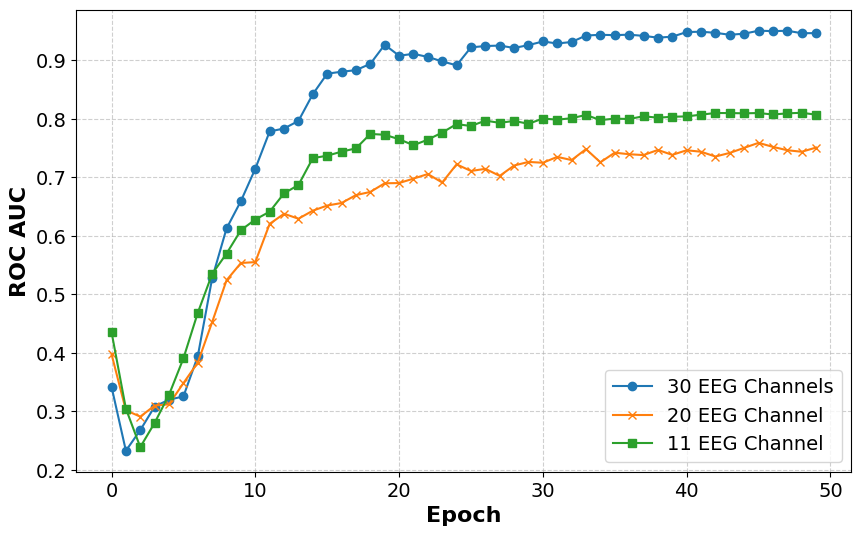

In [ ]:
import json
import matplotlib.pyplot as plt

# Function to extract metrics from a log file
def extract_metrics(log_file):
    epochs = []
    metrics = {
        'train_loss': [], 'val_loss': [], 'test_loss': [],
        'train_class_acc': [], 'val_accuracy': [], 'test_accuracy': [],
        'val_roc_auc': [], 'test_roc_auc': []
    }
    
    with open(log_file, 'r') as f:
        for line in f:
            entry = json.loads(line.strip())  # Parse each line as JSON
            epochs.append(entry['epoch'])
            metrics['train_loss'].append(entry['train_loss'])
            metrics['val_loss'].append(entry['val_loss'])
            metrics['test_loss'].append(entry['test_loss'])
            metrics['train_class_acc'].append(entry['train_class_acc'])
            metrics['val_accuracy'].append(entry['val_balanced_accuracy'])
            metrics['test_accuracy'].append(entry['test_balanced_accuracy'])
            metrics['val_roc_auc'].append(entry['val_roc_auc'])
            metrics['test_roc_auc'].append(entry['test_roc_auc'])
    
    return epochs, metrics

# Modified function to plot 3 lines
def plot_metric_comparison(epochs1, y_values1, epochs2, y_values2, epochs3, y_values3, ylabel, title, label1, label2, label3):
    max_y1 = max(y_values1)
    max_y2 = max(y_values2)
    max_y3 = max(y_values3)

    # Print max values
    print(f"Max {ylabel} for {label1}: {max_y1:.4f}")
    print(f"Max {ylabel} for {label2}: {max_y2:.4f}")
    print(f"Max {ylabel} for {label3}: {max_y3:.4f}")
    
    plt.figure(figsize=(10, 6))
    
    # Adjust line width and marker size for better visibility
    plt.plot(epochs1, y_values1, marker='o', label=label1)
    plt.plot(epochs2, y_values2, marker='x', label=label2)
    plt.plot(epochs3, y_values3, marker='s', label=label3)  # Third dataset
    
    # Set larger font sizes
    plt.xlabel('Epoch', fontsize=16, fontweight='bold')
    plt.ylabel(ylabel, fontsize=16, fontweight='bold')

    # Improve grid and legend readability
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14, loc='best')
    
    plt.show()

# File paths to your log files
log_file1 = 'D:/LaBraM-main/checkpoints/finetune_stress_noleak_30chan_no400up_seed42/log.txt'
log_file2 = 'D:/LaBraM-main/checkpoints/finetune_stress_noleak_20chan_no400up_seed42/log.txt'  # Second log file
log_file3 = 'D:/LaBraM-main/checkpoints/finetune_stress_noleak_11chan_no400up_seed42/log.txt'  # Third log file

# Extract metrics from all three logs
epochs1, metrics1 = extract_metrics(log_file1)
epochs2, metrics2 = extract_metrics(log_file2)
epochs3, metrics3 = extract_metrics(log_file3)

# Plot comparisons with 3 datasets
plot_metric_comparison(epochs1, metrics1['train_loss'], epochs2, metrics2['train_loss'], epochs3, metrics3['train_loss'],
                       'Loss', 'Training Loss over Epochs', '30 EEG Channels', '20 EEG Channel', '11 EEG Channel')

plot_metric_comparison(epochs1, metrics1['val_loss'], epochs2, metrics2['val_loss'], epochs3, metrics3['val_loss'],
                       'Loss', 'Validation Loss over Epochs', '30 EEG Channels', '20 EEG Channel', '11 EEG Channel')

plot_metric_comparison(epochs1, metrics1['test_loss'], epochs2, metrics2['test_loss'], epochs3, metrics3['test_loss'],
                       'Loss', 'Test Loss over Epochs', '30 EEG Channels', '20 EEG Channel', '11 EEG Channel')

plot_metric_comparison(epochs1, metrics1['train_class_acc'], epochs2, metrics2['train_class_acc'], epochs3, metrics3['train_class_acc'],
                       'Accuracy', 'Training Accuracy over Epochs', '30 EEG Channels', '20 EEG Channel', '11 EEG Channel')

plot_metric_comparison(epochs1, metrics1['val_accuracy'], epochs2, metrics2['val_accuracy'], epochs3, metrics3['val_accuracy'],
                       'Accuracy', 'Validation Balanced Accuracy over Epochs', '30 EEG Channels', '20 EEG Channel', '11 EEG Channel')

plot_metric_comparison(epochs1, metrics1['test_accuracy'], epochs2, metrics2['test_accuracy'], epochs3, metrics3['test_accuracy'],
                       'Test Balanced Accuracy', 'Test Balanced Accuracy over Epochs', '30 EEG Channels', '20 EEG Channel', '11 EEG Channel')

plot_metric_comparison(epochs1, metrics1['val_roc_auc'], epochs2, metrics2['val_roc_auc'], epochs3, metrics3['val_roc_auc'],
                       'ROC AUC', 'Validation ROC AUC over Epochs', '30 EEG Channels', '20 EEG Channel', '11 EEG Channel')

plot_metric_comparison(epochs1, metrics1['test_roc_auc'], epochs2, metrics2['test_roc_auc'], epochs3, metrics3['test_roc_auc'],
                       'ROC AUC', 'Test ROC AUC over Epochs', '30 EEG Channels', '20 EEG Channel', '11 EEG Channel')

